# JobFit — Phase 2 : Parsing CV + NLP

Extraction des compétences du CV et premier scoring sémantique contre les offres.

In [10]:
import sys
import os
sys.path.append('../src/nlp')
sys.path.append('../src/api')
os.environ['DB_PATH'] = '../data/processed/jobfit.db'

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/cv', exist_ok=True)

from cv_parser import parse_cv
from embeddings import EmbeddingEngine

plt.style.use('seaborn-v0_8-whitegrid')
print('Librairies chargées.')

Librairies chargées.


## 1. Parsing du CV

In [11]:
cv_data = parse_cv('../data/cv/sample_cv.pdf')

print('\n--- COMPÉTENCES PAR CATÉGORIE ---')
for cat, skills in cv_data['competences_par_categorie'].items():
    print(f'  {cat:20s}: {chr(34)}{chr(34).join(skills)}')

Parsing du CV : ../data/cv/sample_cv.pdf
  Titre          : DATA SCIENTIST - MACHINE LEARNING ENGINEER
  Compétences    : 47 trouvées
  Expérience     : 0 ans
  Formations     : 4

--- COMPÉTENCES PAR CATÉGORIE ---
  langages            : "python"sql"r"scala
  data_analyse        : "pandas"numpy"power bi"plotly"matplotlib"seaborn
  machine_learning    : "scikit-learn"xgboost"lightgbm"random forest"clustering"kmeans"dbscan"gridsearchcv
  nlp                 : "nlp"spacy"nltk"transformers"bert"hugging face"tf-idf"embeddings
  deep_learning       : "tensorflow"keras"pytorch"deep learning
  big_data            : "pyspark"databricks"kafka"airflow
  cloud               : "aws"aws s3"docker"mlflow"fastapi"streamlit
  databases           : "postgresql"mongodb"sqlalchemy
  outils              : "jupyter"github"git"api rest


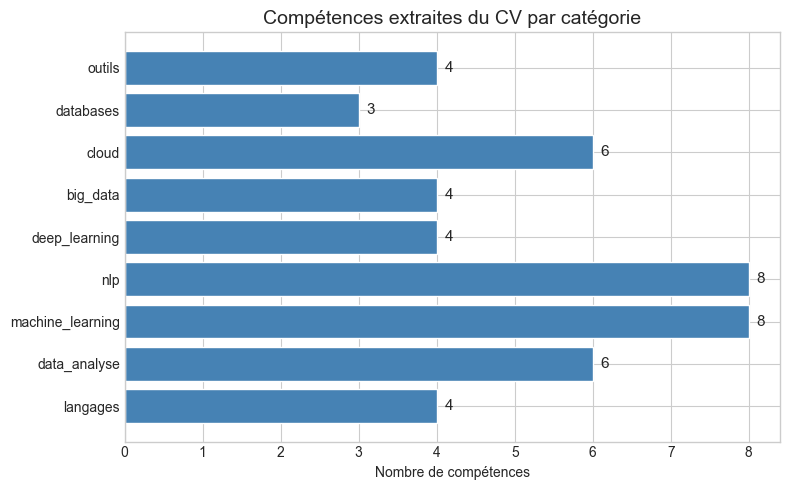

In [12]:
# Visualisation des compétences extraites
cats = cv_data['competences_par_categorie']
labels = list(cats.keys())
sizes = [len(v) for v in cats.values()]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, sizes, color='steelblue', edgecolor='white')
ax.set_title('Compétences extraites du CV par catégorie', fontsize=14)
ax.set_xlabel('Nombre de compétences')
for bar, size in zip(bars, sizes):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(size), va='center', fontsize=11)
plt.tight_layout()
plt.savefig('../data/processed/cv_competences.png', dpi=150)
plt.show()

## 2. Chargement des offres

In [13]:
conn = sqlite3.connect('../data/processed/jobfit.db')
df_offres = pd.read_sql('SELECT * FROM offres', conn)
conn.close()
print(f'Offres chargées : {len(df_offres)}')
df_offres.head(3)

Offres chargées : 6014


,id,intitule,description,date_creation,entreprise,lieu,code_postal,type_contrat,experience,formation,salaire,competences,secteur_activite,code_rome
0,206JNVC,DATA SCIENTIST (H/F),Nouvelle Opportunité - DATA SCIENTIST SENIOR\n...,2026-04-01 17:27:58.450000,SEGMENT ELITE,75 - PARIS,75009,CDI,7 An(s),,Annuel de 45000.0 Euros à 65000.0 Euros sur 12...,Adapter les outils de traitement statistique d...,Conseil en systèmes et logiciels informatiques,M1405
1,206HGSQ,Data Engineer / Data Scientist (H/F),Dans le cadre du renforcement de notre pôle Da...,2026-03-31 20:52:57.628000,ADHOC CONSULT,75 - PARIS 14,75014,CDI,Débutant accepté,Bac+5 et plus ou équivalents,Annuel de 35000.0 Euros à 45000.0 Euros sur 12...,"Analyser, exploiter, structurer des données",Conseil en systèmes et logiciels informatiques,M1811
2,206GRDB,Data scientist (H/F),IRLY réinvente le métier du conseil autour de ...,2026-03-31 14:32:46.495000,IRLY,Ile-de-France,,CDI,Débutant accepté,,Annuel de 40000.0 Euros à 55000.0 Euros sur 12...,Adapter les outils de traitement statistique d...,Conseil pour les affaires et autres conseils d...,M1405


## 3. Génération des embeddings et scoring

In [14]:
engine = EmbeddingEngine()

# Embedding du CV
cv_embedding = engine.embed_text(cv_data['enriched_text'])
print(f'CV embedding shape : {cv_embedding.shape}')

Chargement du modèle : paraphrase-multilingual-MiniLM-L12-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8711.96it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé.
CV embedding shape : (384,)


In [15]:
# Scorer toutes les offres
df_scored = engine.score_cv_vs_offres(cv_embedding, df_offres)

print('\n--- TOP 15 OFFRES LES PLUS COMPATIBLES ---')
cols = ['intitule', 'entreprise', 'lieu', 'type_contrat', 'score_pct']
df_scored[cols].head(15)

Calcul des embeddings pour 6014 offres...


Batches: 100%|██████████| 188/188 [00:28<00:00,  6.60it/s]


--- TOP 15 OFFRES LES PLUS COMPATIBLES ---


,intitule,entreprise,lieu,type_contrat,score_pct
59,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,73.5
52,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,73.5
63,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,73.5
56,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,73.5
54,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,73.5
50,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,73.5
46,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,73.5
58,ALTERNANCE - Data Scientist (H/F),,92 - Boulogne-Billancourt,MIS,71.5
53,Annonce générique - APPRENTISSAGE – Data Scien...,,78 - Versailles,CDD,70.5
51,Annonce générique - APPRENTISSAGE – Data Scien...,,78 - Versailles,CDD,70.5


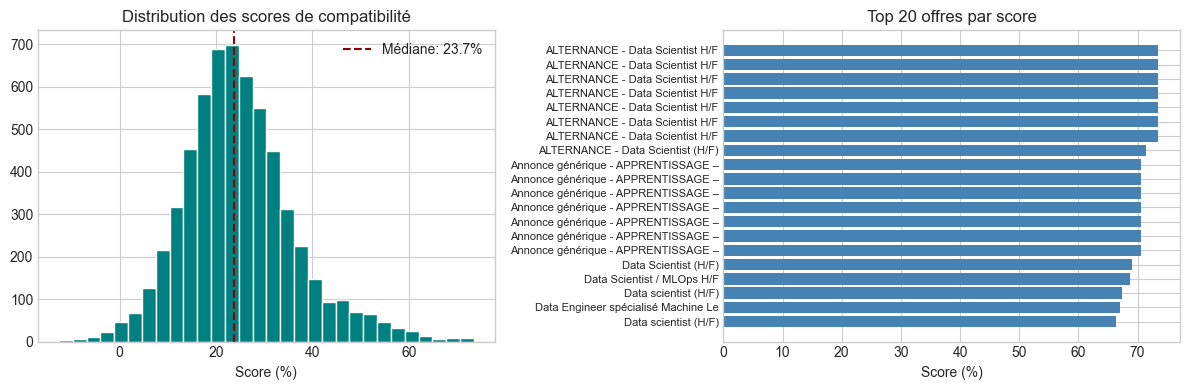

In [16]:
# Distribution des scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_scored['score_pct'], bins=30, color='teal', edgecolor='white')
axes[0].axvline(df_scored['score_pct'].median(), color='darkred',
                linestyle='--', label=f'Médiane: {df_scored["score_pct"].median():.1f}%')
axes[0].set_title('Distribution des scores de compatibilité')
axes[0].set_xlabel('Score (%)')
axes[0].legend()

top20 = df_scored.head(20)
axes[1].barh(range(20), top20['score_pct'], color='steelblue')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([t[:35] for t in top20['intitule']], fontsize=8)
axes[1].set_title('Top 20 offres par score')
axes[1].set_xlabel('Score (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/processed/scoring_results.png', dpi=150)
plt.show()

## 4. Analyse des compétences manquantes

In [17]:
from cv_parser import ALL_SKILLS
import re

cv_skills_set = set(cv_data['competences'])

# Pour chaque offre du top 20, trouver les compétences manquantes
def get_missing_skills(offre_text: str, cv_skills: set) -> list:
    offre_lower = offre_text.lower()
    missing = []
    for skill, _ in ALL_SKILLS:
        if skill not in cv_skills:
            pattern = r'\b' + re.escape(skill) + r'\b'
            if re.search(pattern, offre_lower):
                missing.append(skill)
    return missing

top5 = df_scored.head(5)
print('--- COMPÉTENCES MANQUANTES POUR LES TOP 5 OFFRES ---\n')
for _, row in top5.iterrows():
    offre_text = f"{row['intitule']} {row['description']} {row['competences']}"
    missing = get_missing_skills(offre_text, cv_skills_set)
    print(f"Offre  : {row['intitule'][:50]}")
    print(f"Score  : {row['score_pct']}%")
    print(f"Manque : {', '.join(missing) if missing else 'Rien — profil complet !'}")
    print()

--- COMPÉTENCES MANQUANTES POUR LES TOP 5 OFFRES ---

Offre  : ALTERNANCE - Data Scientist H/F
Score  : 73.5%
Manque : snowflake, azure

Offre  : ALTERNANCE - Data Scientist H/F
Score  : 73.5%
Manque : snowflake, azure

Offre  : ALTERNANCE - Data Scientist H/F
Score  : 73.5%
Manque : snowflake, azure

Offre  : ALTERNANCE - Data Scientist H/F
Score  : 73.5%
Manque : snowflake, azure

Offre  : ALTERNANCE - Data Scientist H/F
Score  : 73.5%
Manque : snowflake, azure



In [18]:
# Sauvegarder les résultats
df_scored.to_csv('../data/processed/offres_scored.csv', index=False)

# Sauvegarder les embeddings offres pour la Phase 3
import numpy as np
textes_offres = [engine.prepare_offre_text(row) for _, row in df_offres.iterrows()]
offres_embeddings = engine.embed_texts(textes_offres)
np.save('../data/processed/offres_embeddings.npy', offres_embeddings)
np.save('../data/processed/cv_embedding.npy', cv_embedding)

print('Fichiers sauvegardés :')
print('  data/processed/offres_scored.csv')
print('  data/processed/offres_embeddings.npy')
print('  data/processed/cv_embedding.npy')

Batches: 100%|██████████| 188/188 [00:27<00:00,  6.85it/s]

Fichiers sauvegardés :
  data/processed/offres_scored.csv
  data/processed/offres_embeddings.npy
  data/processed/cv_embedding.npy
